# 📊 Visualizing ChromaDB: Document Similarity Heatmaps

When you store documents in ChromaDB, how does it know which documents are related to each other, or which document matches your search query?

In this notebook, we visualize the **inner mathematics of ChromaDB** using **Pairwise Similarity Heatmaps**.

### 🎯 Learning Goals:
1. **Extract raw embeddings** directly from ChromaDB (`include=['embeddings']`).
2. **Understand Cosine Similarity**: How 384-dimensional vectors are compared mathematically.
3. **Build a Pairwise Document Heatmap**: See at a glance which documents overlap, cluster, or diverge.
4. **Build an Interactive Plotly Heatmap**: Hover over any cell to see the two documents being compared.
5. **Visualize a Search Query in Action**: See how a new question compares against all stored company documents before ChromaDB returns the top results.

---
## 📐 The Math Behind Vector Similarity

Every document in ChromaDB is represented as a unit vector $\vec{A}$ with 384 coordinates.
To measure how close two documents are in meaning, we calculate the **Cosine Similarity**:

$$\text{Cosine Similarity}(\vec{A}, \vec{B}) = \frac{\vec{A} \cdot \vec{B}}{\|\vec{A}\| \|\vec{B}\|}$$

* **Score = 1.0 (100%)**: Identical semantic meaning.
* **Score ≈ 0.5 - 0.8**: Related topics (e.g., two documents discussing cloud computing and cybersecurity in the tech industry).
* **Score < 0.2**: Completely unrelated topics (e.g., wind turbines vs. clinical gene therapy).

> 💡 **Note on Distance vs. Similarity**:
> * **Cosine Similarity**: Higher is closer ($1.0$ is max).
> * **Cosine Distance** (used by ChromaDB): Lower is closer ($\text{Distance} = 1 - \text{Similarity}$). ChromaDB returns lower distance as top matches.

--- 
## Step 1: Connect to ChromaDB & Fetch Raw Embeddings

Let's load the `company_knowledge` collection we created in Notebook 1, and explicitly ask ChromaDB for its **embeddings**, **documents**, and **metadatas**.

In [1]:
import os
import chromadb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Connect to our existing on-disk ChromaDB
db_directory = os.path.join(os.getcwd(), "chroma_data")
client = chromadb.PersistentClient(path=db_directory)
collection = client.get_collection(name="company_knowledge")

# Fetch all documents with their embeddings
data = collection.get(include=["embeddings", "documents", "metadatas"])

ids = data["ids"]
documents = data["documents"]
metadatas = data["metadatas"]
embeddings = np.array(data["embeddings"])

print(f" Loaded {len(documents)} documents from ChromaDB!")
print(f"📏 Embeddings matrix shape: {embeddings.shape} (Count: {embeddings.shape[0]}, Dimensions: {embeddings.shape[1]})")

 Loaded 5 documents from ChromaDB!
📏 Embeddings matrix shape: (5, 384) (Count: 5, Dimensions: 384)


### 👀 Inspecting a Single Embedding Vector
Let's look at the first few numbers of the vector for Document 1 to demystify what a "vector" looks like:

In [2]:
print(f"Document 1 ID: {ids[0]}")
print(f"Document 1 Text: '{documents[0]}'")
print(f"\nFirst 8 dimensions out of 384 for Document 1:")
print(embeddings[0][:8])

Document 1 ID: doc_001
Document 1 Text: 'TechNova Inc. reported $4.2B in cloud computing revenue, driven by enterprise AI adoption in North America.'

First 8 dimensions out of 384 for Document 1:
[ 0.05625169  0.02007743 -0.00743024 -0.02054838 -0.02339512 -0.00694103
  0.01668506  0.00559643]


--- 
## Step 2: Calculate the Pairwise Cosine Similarity Matrix

We now calculate the similarity score between every possible pair of documents.  
Using NumPy, we normalize each vector to length 1 and calculate the dot product matrix: $S = V_{norm} \times V_{norm}^T$.

In [3]:
# Normalize embeddings to unit vectors (magnitude = 1)
norms = np.linalg.norm(embeddings, axis=1, keepdims=True)
normalized_embeddings = embeddings / norms

# Compute pairwise dot product (Cosine Similarity Matrix: N x N)
similarity_matrix = np.dot(normalized_embeddings, normalized_embeddings.T)

# Create friendly labels using Company Name + Topic
labels = [
    f"{m.get('company', 'Unknown')}: {m.get('topic', 'Topic')}"
    for m in metadatas
]

# Display as a clean DataFrame
sim_df = pd.DataFrame(similarity_matrix, index=labels, columns=labels)
sim_df.round(3)

,TechNova: cloud_revenue,BioHealth: fda_approval,EcoEnergy: wind_power,TechNova: cybersecurity,RetailPulse: store_sales
TechNova: cloud_revenue,1.000,0.155,0.215,0.482,0.241
BioHealth: fda_approval,0.155,1.000,0.104,0.090,0.043
EcoEnergy: wind_power,0.215,0.104,1.000,0.059,0.022
TechNova: cybersecurity,0.482,0.090,0.059,1.000,0.057
RetailPulse: store_sales,0.241,0.043,0.022,0.057,1.000


--- 
## Step 3: Visualizing with a Static Seaborn Heatmap

Let's plot this matrix as a color-coded heatmap:  
- **Diagonal line (top-left to bottom-right)** is always `1.00` because every document is 100% identical to itself.
- Notice how **TechNova: cloud_revenue** and **TechNova: cybersecurity** have a much higher similarity score than **TechNova** and **BioHealth**!

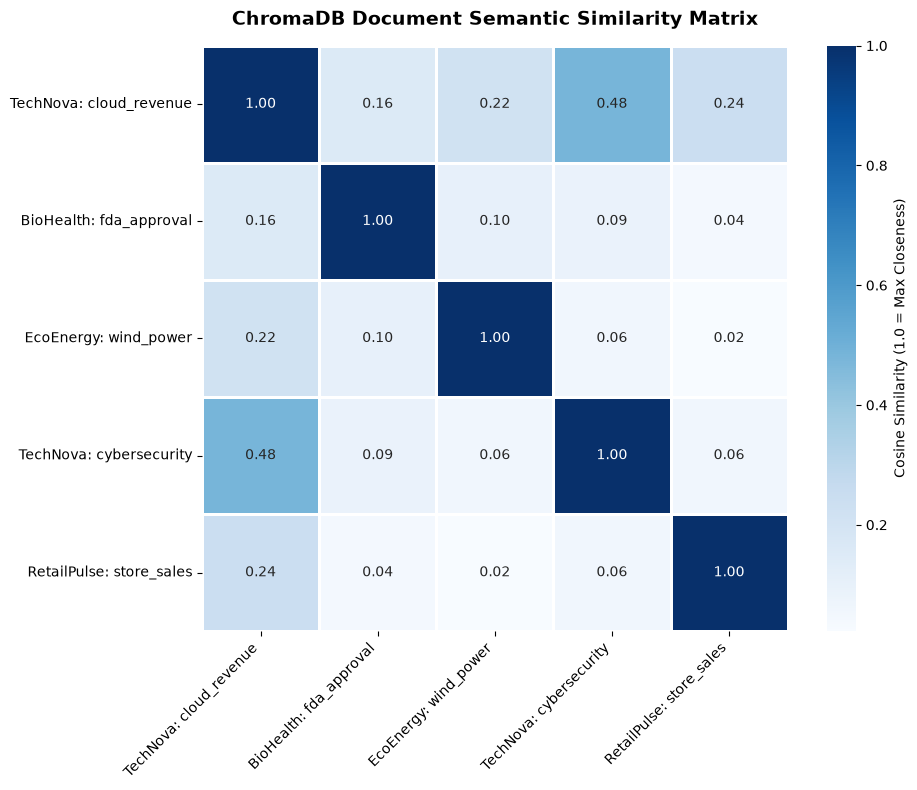

In [4]:
plt.figure(figsize=(10, 8))

# Plot heatmap with 'viridis' color palette
sns.heatmap(
    sim_df,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    cbar_kws={"label": "Cosine Similarity (1.0 = Max Closeness)"},
    linewidths=1,
    linecolor="white",
    square=True
)

plt.title("ChromaDB Document Semantic Similarity Matrix", fontsize=14, fontweight="bold", pad=15)
plt.xticks(rotation=45, ha="right", fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.show()

--- 
## Step 4: Interactive Plotly Heatmap (Hover to Read Content)

With large company data, labels alone aren't enough—you want to read the text chunks when inspecting similarity!  
With this Plotly interactive visualization, you can **hover your cursor over any square** to inspect both documents and their exact score.

In [5]:
# Prepare hover text containing document excerpts
hover_text = []
for i in range(len(documents)):
    row_text = []
    for j in range(len(documents)):
        score = similarity_matrix[i, j]
        text = (
            f"<b>Doc A ({labels[i]}):</b><br>{documents[i][:90]}...<br><br>"
            f"<b>Doc B ({labels[j]}):</b><br>{documents[j][:90]}...<br><br>"
            f"<b>Similarity Score:</b> {score:.4f}"
        )
        row_text.append(text)
    hover_text.append(row_text)

fig = px.imshow(
    similarity_matrix,
    x=labels,
    y=labels,
    color_continuous_scale="Viridis",
    zmin=0,
    zmax=1,
    labels=dict(color="Similarity"),
    title="Interactive Document Semantic Heatmap (Hover over cells to compare!)"
)

fig.update_traces(hoverinfo="text", text=hover_text)
fig.update_layout(width=750, height=650, title_font=dict(size=16))
fig.show()

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

--- 
## Step 5: Visualizing a Query Ranking Heatmap (Search in Action)

What happens when you search?  
Let's pass a query: `"Which company produces clean renewable energy from wind?"`  
We will embed the query using ChromaDB's embedding function, calculate the similarity against every document, and visualize the **search relevance bar**.

🔍 Query: 'Which company produces clean renewable energy from wind?'

                Document  Similarity Score
   EcoEnergy: wind_power          0.542635
 BioHealth: fda_approval          0.210557
 TechNova: cloud_revenue          0.161751
 TechNova: cybersecurity          0.114602
RetailPulse: store_sales          0.006484


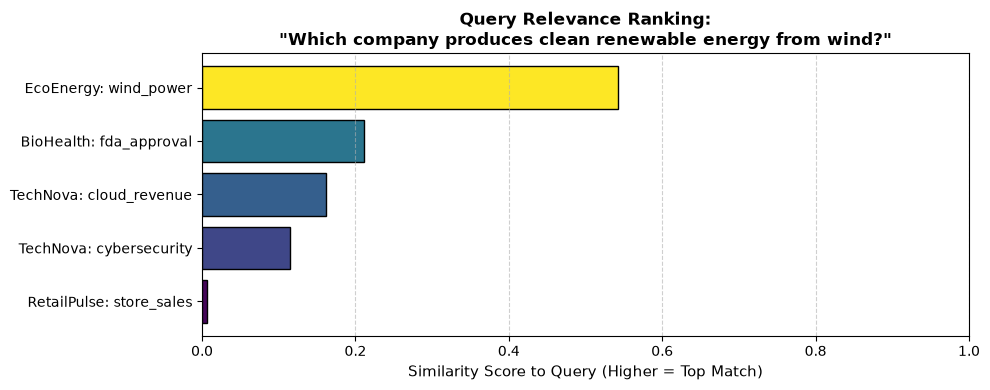

In [6]:
from chromadb.utils import embedding_functions

# ChromaDB's default embedding function
default_ef = embedding_functions.DefaultEmbeddingFunction()

# 1. Define a user search query
test_query = "Which company produces clean renewable energy from wind?"

# 2. Generate vector embedding for the query
query_embedding = np.array(default_ef([test_query])[0])
query_norm = query_embedding / np.linalg.norm(query_embedding)

# 3. Compute cosine similarity between the query and all stored documents
query_similarities = np.dot(normalized_embeddings, query_norm)

# 4. Build a ranking DataFrame
rank_df = pd.DataFrame({
    "Document": labels,
    "Similarity Score": query_similarities,
    "Content Excerpt": [d[:85] + "..." for d in documents]
}).sort_values(by="Similarity Score", ascending=False)

print(f"🔍 Query: '{test_query}'\n")
print(rank_df[["Document", "Similarity Score"]].to_string(index=False))

# 5. Visualize as a horizontal similarity ranking chart
plt.figure(figsize=(10, 4))
colors = plt.cm.viridis(rank_df["Similarity Score"] / rank_df["Similarity Score"].max())
bars = plt.barh(rank_df["Document"][::-1], rank_df["Similarity Score"][::-1], color=colors[::-1], edgecolor="black")

plt.xlabel("Similarity Score to Query (Higher = Top Match)", fontsize=11)
plt.title(f"Query Relevance Ranking:\n\"{test_query}\"", fontsize=12, fontweight="bold")
plt.xlim(0, 1.0)
plt.grid(axis="x", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

--- 
## 💡 Takeaways: How This Helps With Large Company Data

1. **Spotting Information Density**: When you ingest 1,000s of company documents, heatmaps help you see if documents from different divisions are distinct or duplicating each other.
2. **Diagnosing Poor Search Results**: If ChromaDB returns unexpected results for a query, plotting the similarity scores immediately tells you if the query was too vague or if multiple documents have competing similarity.
3. **Thresholding**: In real production systems, you can set a **cutoff threshold** (e.g., discard any chunk with similarity < 0.45) so your LLM doesn't receive irrelevant garbage.

**Next Up**: In Notebook 3, we will build the **Large Company Data Ingestion Pipeline** (chunking, automated metadata extraction, and batching)!